<a href="https://colab.research.google.com/github/Chepngetich/AI-for-Science-and-Engineering/blob/main/DArTseq_Week4_Descriptive_Statistics_and_Correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4: Descriptive Statistics, Covariance and Correlation of DArTseq SNP Data

**Project:** Machine learning and deep learning for imputation of missing and uncertain genotypes in sequencing-derived SNP datasets.

This notebook uses the same real DArTseq SNP dataset imported in Week 3. The public dataset contains 8,649 SNPs for 430 koala individuals, generated using DArTseq.


## 1. Import the dataset

If `genotypes_file.csv` is already in the Colab working directory, it will be loaded automatically. Otherwise, upload the same DArTseq genotype file used in Week 3.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_NAME = "genotypes_file.csv"

if not os.path.exists(FILE_NAME):
    from google.colab import files
    print("Please upload the same genotypes_file.csv used in Week 3.")
    uploaded = files.upload()
    if FILE_NAME not in uploaded:
        FILE_NAME = list(uploaded.keys())[0]

df = pd.read_csv(FILE_NAME)

print("Dataset shape:", df.shape)
display(df.head(10))


Please upload the same genotypes_file.csv used in Week 3.


Saving genotypes_file.csv to genotypes_file.csv
Dataset shape: (17303, 447)


/tmp/ipykernel_2603/225234176.py:15: DtypeWarning: Columns (4,5,6,7,8,9,10,11,12,13,14,15,16,186) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILE_NAME)


,*,*.1,*.2,*.3,*.4,*.5,*.6,*.7,*.8,*.9,...,Unnamed: 437,Unnamed: 438,Unnamed: 439,Unnamed: 440,Unnamed: 441,Unnamed: 442,Unnamed: 443,Unnamed: 444,Unnamed: 445,Unnamed: 446
0,*,*,*,*,*,*,*,*,*,*,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,*,*,*,*,*,*,*,*,*,*,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,*,*,*,*,*,*,*,*,*,*,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,*,*,*,*,*,*,*,*,*,*,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AlleleID,AlleleSequence,TrimmedSequence,SNP,SnpPosition,CallRate,OneRatioRef,OneRatioSnp,FreqHomRef,FreqHomSnp,...,Koala_331,Koala_339,Koala_14,Koala_135,Koala_218,Koala_329,Koala_313,Koala_54,Koala_41,Koala_125
5,12488767|F|0--14:A>G,Example sequence,Example Trimmed sequence,NaN,14,1,0.989384,0.195329,0.804671,0.010616,...,1,1,1,1,1,1,1,1,1,1
6,12488767|F|0-14:A>G-14:A>G,Example sequence,Example Trimmed sequence,14:A>G,14,1,0.989384,0.195329,0.804671,0.010616,...,0,0,0,0,0,0,0,1,1,0
7,32285996|F|0--38:T>A,Example sequence,Example Trimmed sequence,NaN,38,0.942675,0.957207,0.272523,0.727477,0.042793,...,1,1,1,1,1,-,1,1,1,1
8,32285996|F|0-38:T>A-38:T>A,Example sequence,Example Trimmed sequence,38:T>A,38,0.942675,0.957207,0.272523,0.727477,0.042793,...,0,1,0,0,1,-,0,0,1,0
9,100006527|F|0--22:A>C,Example sequence,Example Trimmed sequence,NaN,22,0.864119,0.002457,1,0,0.997543,...,0,0,0,0,0,-,0,0,0,0


## 2. Identify numerical SNP variables

For this project, the numerical variables are SNP genotype calls. Common missing-value symbols are converted to missing values, and columns that are sufficiently numeric are identified.


In [2]:
clean = df.replace(["-", "NA", "N/A", "", "null", "None"], np.nan)
numeric_df = clean.apply(pd.to_numeric, errors="coerce")

numeric_candidates = []
for col in numeric_df.columns:
    non_missing_fraction = numeric_df[col].notna().mean()
    if non_missing_fraction >= 0.80 and numeric_df[col].nunique(dropna=True) >= 2:
        numeric_candidates.append(col)

print("Potential numerical variables:", len(numeric_candidates))
print(numeric_candidates[:20])


Potential numerical variables: 428
['*.4', '*.5', '*.6', '*.7', '*.8', '*.9', '*.10', '*.11', '*.12', '*.13', '*.14', '*.15', '*.16', 'These rows contain information about sample and order number from Diversity Arrays, and can be left blank if you are reformatting data to the appropriate dartR format', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23']


## 3. Select 2–4 numerical variables

The notebook selects four SNP variables with high completeness and useful variation. These variables will be used for the descriptive-statistics exercise.


In [3]:
variances = numeric_df[numeric_candidates].var(skipna=True).sort_values(ascending=False)
selected_variables = variances.head(min(4, len(variances))).index.tolist()

print("Selected variables:")
for i, col in enumerate(selected_variables, 1):
    print(f"{i}. {col}")

selected_data = numeric_df[selected_variables].copy()
display(selected_data.head(10))


Selected variables:
1. *.14
2. *.4
3. *.15
4. Unnamed: 417


,*.14,*.4,*.15,Unnamed: 417
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,25.10442,14.0,13.68182,1.0
6,25.10442,14.0,13.68182,0.0
7,8.16667,38.0,4.96503,1.0
8,8.16667,38.0,4.96503,0.0
9,6.00000,22.0,4.30722,NaN


## 4. Calculate mean, median, range, variance and standard deviation

For each selected numerical SNP variable, calculate the required descriptive statistics.


In [4]:
statistics = pd.DataFrame(index=selected_variables)
statistics["Mean"] = selected_data.mean()
statistics["Median"] = selected_data.median()
statistics["Range"] = selected_data.max() - selected_data.min()
statistics["Variance"] = selected_data.var()
statistics["Standard Deviation"] = selected_data.std()

display(statistics.round(4))


,Mean,Median,Range,Variance,Standard Deviation
*.14,22.4266,15.745,245.4909,339.9996,18.4391
*.4,33.8727,32.000,63.0000,336.2214,18.3363
*.15,16.5622,11.800,232.6371,179.7874,13.4085
Unnamed: 417,0.5778,1.000,1.0000,0.2440,0.4939


## 5. Covariance and correlation

The first two selected SNP variables are used to calculate covariance and Pearson correlation.


In [5]:
var_x = selected_variables[0]
var_y = selected_variables[1]

pair = selected_data[[var_x, var_y]].dropna()

covariance = pair[var_x].cov(pair[var_y])
correlation = pair[var_x].corr(pair[var_y])

print("Variable 1:", var_x)
print("Variable 2:", var_y)
print(f"Covariance: {covariance:.4f}")
print(f"Pearson correlation: {correlation:.4f}")


Variable 1: *.14
Variable 2: *.4
Covariance: -51.9037
Pearson correlation: -0.1535


## 6. Plot the relationship between the two variables


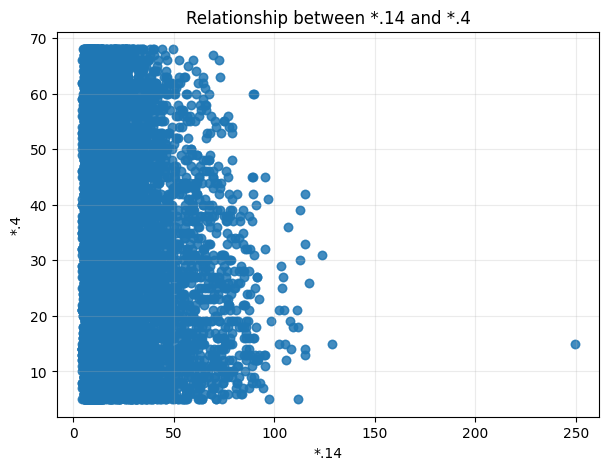

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(pair[var_x], pair[var_y], alpha=0.6)
plt.xlabel(var_x)
plt.ylabel(var_y)
plt.title(f"Relationship between {var_x} and {var_y}")
plt.grid(True, alpha=0.25)
plt.show()


## 7. Input → Function/Model → Output

For the genotype-imputation project, one SNP can be considered an input and another SNP can be considered the output that a model attempts to predict.

**Input:** observed genotype information at SNP X  
**Function/Model:** a machine-learning function `f(·)`  
**Output:** predicted genotype at SNP Y

The mathematical idea is:

$$
\hat{Y} = f(X)
$$

where `X` is the observed genotype information used as input, `f` is the learned ML model, and `Ŷ` is the predicted genotype.


## 8. Short project interpretation

The descriptive statistics provide an overview of the distribution and variability of the selected SNP genotype variables. The mean and median describe central tendency, while the range, variance, and standard deviation describe variation among individuals.

The covariance indicates whether the two selected SNP variables tend to vary together, while Pearson correlation gives a standardized measure of the strength and direction of their linear association.

Correlation does not establish causation. In genomic data, an association between two SNPs may result from linkage disequilibrium, shared population structure, common ancestry, or other factors. Therefore, correlation can identify a relationship but cannot by itself demonstrate that one SNP causes a change in another.
